# ==============================
# 1. IMPORT LIBRARIES
# ==============================

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# 2. LOAD DATASET
# ==============================
# https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data


In [3]:
df = pd.read_csv("dataset/bitcoin.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7509286 entries, 0 to 7509285
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 343.7 MB
None


# ==============================
# 3. DATA CLEANING
# ==============================

In [4]:
# Convert datetime if exists
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day

In [5]:
# Handle missing values
df = df.ffill()

In [13]:
# Remove duplicates
df = df.drop_duplicates()

print("\nAfter cleaning:")
print(df.head())


After cleaning:
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


# ==============================
# 4. FEATURE SELECTION
# ==============================
# Typical Bitcoin dataset columns:
# open, high, low, close, volume

In [14]:
# Predict "close" price
target = "close"

features = [col for col in df.columns if col != target and df[col].dtype != "object"]

X = df[features]
y = df[target]

print("\nFeatures:", features)


Features: ['Timestamp', 'Open', 'High', 'Low', 'Volume']


# ==============================
# 5. TRAIN-TEST SPLIT
# ==============================

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# ==============================
# 6. SCALING
# ==============================

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 7. MODEL TRAINING
# ==============================

In [17]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [18]:
# Model 2: Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

# ==============================
# 8. PREDICTIONS
# ==============================

In [19]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test_scaled)

# ==============================
# 9. EVALUATION
# ==============================

In [20]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)



Linear Regression Performance:
MAE: 10.018212614231134
MSE: 351.01993938436533
R2 Score: 0.9999995570953102

Decision Tree Performance:
MAE: 13564.64676967463
MSE: 473202049.66006666
R2 Score: 0.40293019423792187


# ==============================
# 10. VISUALIZATION
# ==============================

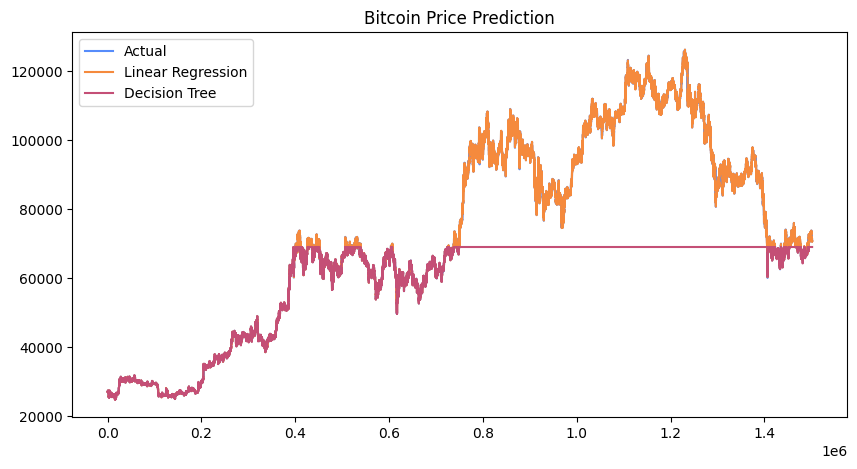

In [21]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Linear Regression")
plt.plot(y_pred_dt, label="Decision Tree")
plt.legend()
plt.title("Bitcoin Price Prediction")
plt.show()

# ==============================
# 11. SIMPLE FUTURE PREDICTION
# ==============================

In [22]:
sample = X_test_scaled[-1].reshape(1, -1)

print("\nNext Prediction:")
print("Linear Regression:", lr.predict(sample))
print("Decision Tree:", dt.predict(sample))


Next Prediction:
Linear Regression: [70755.55432802]
Decision Tree: [69000.]


##  What this project covers (mapped to your training)

- Data loading (Pandas)
- Cleaning (missing values, datetime)
- Feature engineering
- Train/Test split
- Scaling
- Model training (2 models)
- Evaluation (MAE, MSE, R²)
- Visualization
- Final prediction

---

##  Dataset Recommendation (Important)

Download from:
- Kaggle → search: **"Bitcoin Historical Data"**

Make sure it includes:
- datetime
- open
- high
- low
- close
- volume